In [1]:
import os
import random
import numpy as np
import pandas as pd

import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from tqdm.auto import tqdm

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [2]:
#Cek apakah GPU tersedia
print("="*50)

print("Torch Version :", torch.__version__)

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA :", torch.version.cuda)

    device = torch.device("cuda")

else:

    print("Menggunakan CPU")

    device = torch.device("cpu")

print("="*50)

Torch Version : 2.11.0+cu128
CUDA Available : True
GPU : NVIDIA GeForce RTX 3060 Ti
CUDA : 12.8


In [3]:
#Load dataset
DATA_PATH = "../output/dataset_preprocessing.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(20807, 9)


,label,author,comment,id,channel,title,cleaning,casefolding,hasil_preprocessing
0,1,Abatistalima-b4t,"AЕR𝐎𝟴𝟴 gua main dikit aja, saldo lngsg nambah",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 gua main dikit aja saldo lngsg nambah,aero88 gua main dikit aja saldo lngsg nambah,aero88 gua main dikit aja saldo lngsg nambah
1,1,AbdulkadirMustafa-z4t,Sebelumnya bermain di tempat lain terasa kuran...,CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,Sebelumnya bermain di tempat lain terasa kuran...,sebelumnya bermain di tempat lain terasa kuran...,sebelumnya bermain di tempat lain terasa kuran...
2,1,abdullaGodgift-m1w,AЕR𝐎𝟴𝟴 aku sih gmpang bgt dapet WEDEY gede dsini,CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 aku sih gmpang bgt dapet WEDEY gede dsini,aero88 aku sih gmpang bgt dapet wedey gede dsini,aero88 aku sih gmpang bgt dapet wedey gede dsini
3,1,AbdullahFABIAN-i2m,"AЕR𝐎𝟴𝟴 gua cba bentar, eh lgnsung dapet jackpot",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 gua cba bentar eh lgnsung dapet jackpot,aero88 gua cba bentar eh lgnsung dapet jackpot,aero88 gua cba bentar eh lgnsung dapet jackpot
4,1,Abergerontorres-s3d,"AЕR𝐎𝟴𝟴 aku cba maen, malah jackpot gede",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 aku cba maen malah jackpot gede,aero88 aku cba maen malah jackpot gede,aero88 aku cba maen malah jackpot gede


In [4]:
DATA_PATH = "../output/dataset_preprocessing.csv"

df = pd.read_csv(DATA_PATH)

print("="*50)
print("Ukuran Dataset :", df.shape)
print("="*50)

print(df[["hasil_preprocessing", "label"]].head())

print("\nDistribusi Label")

print(df["label"].value_counts())

print("\nPersentase")

print(df["label"].value_counts(normalize=True)*100)

Ukuran Dataset : (20807, 9)
                                 hasil_preprocessing  label
0       aero88 gua main dikit aja saldo lngsg nambah      1
1  sebelumnya bermain di tempat lain terasa kuran...      1
2   aero88 aku sih gmpang bgt dapet wedey gede dsini      1
3     aero88 gua cba bentar eh lgnsung dapet jackpot      1
4             aero88 aku cba maen malah jackpot gede      1

Distribusi Label
label
1    10532
0    10275
Name: count, dtype: int64

Persentase
label
1    50.617581
0    49.382419
Name: proportion, dtype: float64


In [5]:
print(df.isnull().sum())

label                    0
author                   0
comment                  0
id                       0
channel                  0
title                    0
cleaning               102
casefolding            102
hasil_preprocessing    102
dtype: int64


In [6]:
df = df.dropna(subset=["hasil_preprocessing"])

In [7]:
#split dataset menjadi train dan test
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("="*50)

print("Train      :", len(train_df))
print("Validation :", len(valid_df))
print("Test       :", len(test_df))

print("="*50)

Train      : 16564
Validation : 2070
Test       : 2071


In [8]:
print("Train")
print(train_df["label"].value_counts(normalize=True))

print()

print("Validation")
print(valid_df["label"].value_counts(normalize=True))

print()

print("Test")
print(test_df["label"].value_counts(normalize=True))

Train
label
1    0.508694
0    0.491306
Name: proportion, dtype: float64

Validation
label
1    0.508696
0    0.491304
Name: proportion, dtype: float64

Test
label
1    0.50845
0    0.49155
Name: proportion, dtype: float64


In [9]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [10]:
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [11]:
sample = train_df["hasil_preprocessing"].iloc[0]

encoding = tokenizer(
    sample,
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH
)

print(sample)
print()
print(encoding.keys())

jane roy suryo iku orang apa c kk ngeyel melu gregeten q

KeysView({'input_ids': [2, 20979, 6064, 25281, 880, 30360, 232, 387, 61, 7819, 21968, 6885, 30366, 147, 30360, 19924, 12123, 30355, 903, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [12]:
from torch.utils.data import Dataset

class IndoBERTDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length):

        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {

            "input_ids": encoding["input_ids"].flatten(),

            "attention_mask": encoding["attention_mask"].flatten(),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )

        }

In [13]:
train_dataset = IndoBERTDataset(

    train_df["hasil_preprocessing"],
    train_df["label"],
    tokenizer,
    MAX_LENGTH

)

valid_dataset = IndoBERTDataset(

    valid_df["hasil_preprocessing"],
    valid_df["label"],
    tokenizer,
    MAX_LENGTH

)

test_dataset = IndoBERTDataset(

    test_df["hasil_preprocessing"],
    test_df["label"],
    tokenizer,
    MAX_LENGTH

)

print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

16564
2070
2071


In [14]:
BATCH_SIZE = 16

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

In [16]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)

print(batch["attention_mask"].shape)

print(batch["labels"].shape)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16])


In [17]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=2

)

model.to(device)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [18]:
EPOCHS = 3

LEARNING_RATE = 2e-5

In [19]:
from torch.optim import AdamW

optimizer = AdamW(

    model.parameters(),

    lr=LEARNING_RATE

)

In [20]:
from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(

    optimizer,

    num_warmup_steps=0,

    num_training_steps=total_steps

)

In [21]:
from sklearn.metrics import accuracy_score

def train_epoch(model, dataloader, optimizer, scheduler, device):

    model.train()

    total_loss = 0
    predictions = []
    labels = []

    for batch in tqdm(dataloader, desc="Training"):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        target = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=target
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        labels.extend(target.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(labels, predictions)

    return avg_loss, accuracy

In [22]:
def eval_epoch(model, dataloader, device):

    model.eval()

    total_loss = 0
    predictions = []
    labels = []

    with torch.no_grad():

        for batch in tqdm(dataloader, desc="Validation"):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            target = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=target
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            labels.extend(target.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(labels, predictions)

    return avg_loss, accuracy

In [23]:
EPOCHS = 3

best_accuracy = 0

history = {

    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []

}

In [24]:
import os

MODEL_PATH = "../model/indobert_best"

os.makedirs(MODEL_PATH, exist_ok=True)

for epoch in range(EPOCHS):

    print("="*60)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("="*60)

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        device
    )

    val_loss, val_acc = eval_epoch(
        model,
        valid_loader,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print()

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print()

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        model.save_pretrained(MODEL_PATH)

        tokenizer.save_pretrained(MODEL_PATH)

        print("\nModel terbaik disimpan.")

Epoch 1/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]


Train Loss : 0.1207
Train Acc  : 0.9649

Val Loss   : 0.1108
Val Acc    : 0.9700


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model terbaik disimpan.
Epoch 3/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]


Train Loss : 0.0409
Train Acc  : 0.9848

Val Loss   : 0.1066
Val Acc    : 0.9710


In [25]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    "../output/training_history.csv",
    index=False
)

history_df.head()

,train_loss,train_acc,val_loss,val_acc
0,0.120659,0.964864,0.110818,0.970048
1,0.066904,0.979292,0.100096,0.972464
2,0.040902,0.984786,0.106633,0.971014


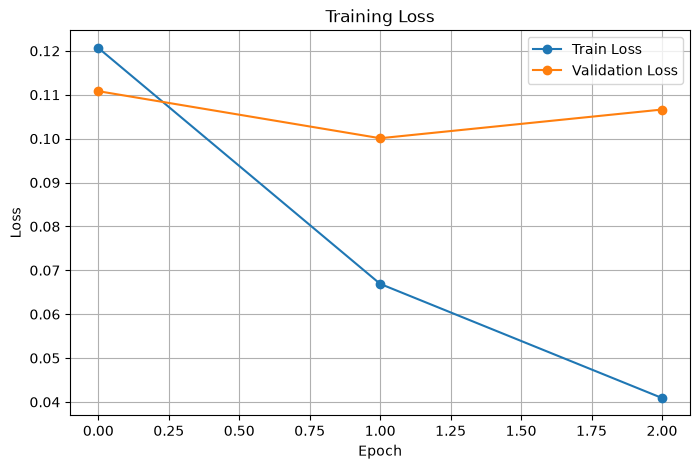

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid(True)

plt.show()

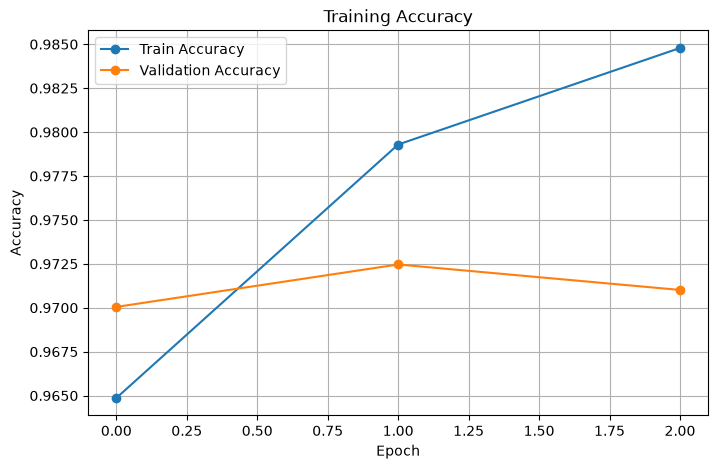

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.grid(True)

plt.show()